a label-preprocessing pipeline that automatically deskews a rotated label and computes a sharpness score before OCR.

In [42]:
import cv2 as cv
from cv2 import imread,imshow
import numpy as np
import matplotlib.pyplot as plt
import time

In [ ]:
def deskew(image,contour):
    #getting the sharpness for orignal image with width and height
    sharpness_before=cv.Laplacian(image,cv.CV_64F).var()
    h,w=image.shape[:2]

    #passing the biggest contour to the min rect and get angle
    ret=cv.minAreaRect(contour)
    angle=ret[-1]

    # angle correction 
    if angle < -45:
        angle=-(90+angle)   
    else:
        angle=-angle
    
    # setting the kernel for deskew 
    center=(w//2,h//2)
    rotate_kernel=cv.getRotationMatrix2D(center,-angle,1)

    #correct the image for the angle
    corrected_image=cv.warpAffine(image,rotate_kernel,(w,h))

    # geeting the varince for the corrected_image 
    sharpness_after=cv.Laplacian(corrected_image,cv.CV_64F).var()

    confidence='high' if sharpness_before-sharpness_after<50 else 'low'

    return {
        'corrected_image':corrected_image,
        'angle':angle,
        'sharpness_before':sharpness_before,
        'sharpness_after':sharpness_after,
        'confidence':confidence
    }


In [44]:
def process_label(src,sharpness_threshold=100):
    start_time=time.perf_counter()

    # loading the image 
    image=cv.imread(src)

    # checking if the image is been loaded suceessfully 
    if image is None:
        print('Could not able to load the image')
    
    # clearing the noise 
    gray=cv.cvtColor(image,cv.COLOR_BGR2GRAY)
    denoised=cv.medianBlur(gray,3)

    # making the main label visible 
    _,thresh=cv.threshold(denoised,100,255,cv.THRESH_BINARY_INV)
    cleaning=cv.morphologyEx(thresh,cv.MORPH_CLOSE,(3,3))
    plt.imshow(cleaning,cmap='gray')

    # finding and getting the biggest contour 
    contour,_=cv.findContours(cleaning,cv.RETR_EXTERNAL,cv.CHAIN_APPROX_SIMPLE)
    max_contour=max(contour,key=cv.contourArea)

    result=deskew(gray,max_contour)

    processing_time=(time.perf_counter()-start_time)*1000
    is_usable=(result['sharpness_after']>=sharpness_threshold)

    return{
        'corrected_image':result['corrected_image'],
        'detected_angle_deg':result['angle'],
        'sharpness_before':result['sharpness_before'],
        'sharpness_after':result['sharpness_after'],
        'total_pipeline_time':round(processing_time,3),
        'is_usable':is_usable,
        'confidence':result['confidence']
    }

Detected angle:11.361411094665527
Corrected Image sharpness:85.37554911995225
Original Image sharpness:132.8191571400267
Processing Time:176.478
Confidence:high
Is usable: True


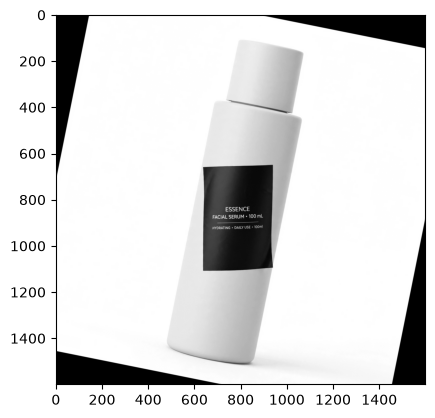

In [50]:
result1=process_label('../media/Photos/project/tilted_label1.png')
plt.imshow(result1['corrected_image'],cmap='gray')
print(
    f'Detected angle:{result1['detected_angle_deg']}',
    f'Corrected Image sharpness:{result1['sharpness_before']}',
    f'Original Image sharpness:{result1['sharpness_after']}',
    f'Processing Time:{result1['total_pipeline_time']}',
    f'Confidence:{result1['confidence']}',
    f'Is usable: {result1['is_usable']}',
    sep='\n'
)

Detected angle:-0.27154541015625
Corrected Image sharpness:65.16490805237466
Original Image sharpness:152.93374493523822
Processing Time:164.284
Confidence:high
Is usable: True


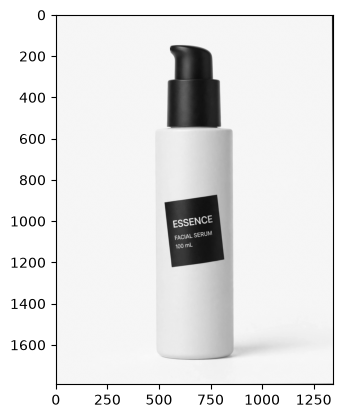

In [46]:
result1=process_label('../media/Photos/project/tilted_label2.png')
plt.imshow(result1['corrected_image'],cmap='gray')
print(
    f'Detected angle:{result1['detected_angle_deg']}',
    f'Corrected Image sharpness:{result1['sharpness_before']}',
    f'Original Image sharpness:{result1['sharpness_after']}',
    f'Processing Time:{result1['total_pipeline_time']}',
    f'Confidence:{result1['confidence']}',
    f'Is usable: {result1['is_usable']}',
    sep='\n'
)

Detected angle:19.983104705810547
Corrected Image sharpness:67.23113903462887
Original Image sharpness:137.102679376602
Processing Time:134.328
Confidence:high
Is usable: True


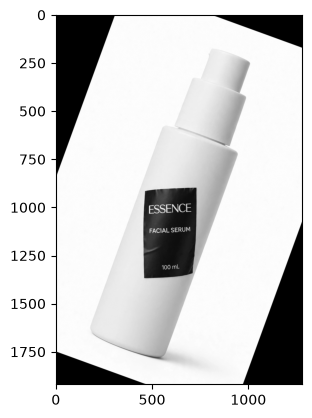

In [52]:
result1=process_label('../media/Photos/project/tilted_label3.png')
plt.imshow(result1['corrected_image'],cmap='gray')
print(
    f'Detected angle:{result1['detected_angle_deg']}',
    f'Corrected Image sharpness:{result1['sharpness_before']}',
    f'Original Image sharpness:{result1['sharpness_after']}',
    f'Processing Time:{result1['total_pipeline_time']}',
    f'Confidence:{result1['confidence']}',
    f'Is usable: {result1['is_usable']}',
    sep='\n'
)

Detected angle:28.61046028137207
Corrected Image sharpness:93.92285345492986
Original Image sharpness:163.19529856398444
Processing Time:188.777
Confidence:high
Is usable: True


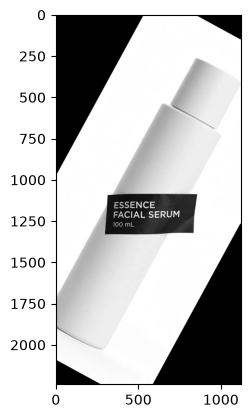

In [48]:
result1=process_label('../media/Photos/project/tilted_label4.png')
plt.imshow(result1['corrected_image'],cmap='gray')
print(
    f'Detected angle:{result1['detected_angle_deg']}',
    f'Corrected Image sharpness:{result1['sharpness_before']}',
    f'Original Image sharpness:{result1['sharpness_after']}',
    f'Processing Time:{result1['total_pipeline_time']}',
    f'Confidence:{result1['confidence']}',
    f'Is usable: {result1['is_usable']}',
    sep='\n'
)